# SOUS VIDE Examples Notebook
This notebook shows you how to generate two example policies from the SOUS VIDE paper; the policy flown for the robustness tests and the policy flown in the cluttered backroom.

Some useful settings for interactive work

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib widget

Import the relevant modules

In [2]:
import torch
torch.set_float32_matmul_precision('high')

import sousvide.synthesize.rollout_generator as rg
import sousvide.synthesize.observation_generator as og
import sousvide.instruct.train_policy as tp
import sousvide.visualize.plot_synthesize as ps
import sousvide.visualize.plot_synthesize as ps
import sousvide.visualize.plot_learning as pl
import sousvide.flight.deploy_figs as df

#### 1. Define the desired scene and course to train on.

In [3]:
# =========================================
# Robustness Test
# =========================================

cohort = "aerial_arena"               # Cohort name (parent folder) for the robustness test
scene = "aerialarena_square_16x/splatfacto/2026-07-30_141201_clean"                  # Scene name for the robustness test
courses = ["aerialarena_test"]              # Courses to be used in the robustness test

# # =========================================
# # Cluttered Test
# # =========================================

# cohort = "cluttered"               # Cohort name (parent folder) for the cluttered test
# scene = "backroom"                  # Scene name for the cluttered test
# courses = ["circuit"]              # Courses to be used in the cluttered test

#### 2. Define the SOUS VIDE policy to train/evaluate.

Feel free to use Maverick as a reference to add more pilots in the configs/pilots folder. The configs allow users to create diverse variations of the policy without having to change package level code. We have an example of this (Iceman) where we remove velocity and height estimates.

Use data_alpha for your data method as a small initial test. It gives performance close to the published results within a shorter training time. Use data_beta/data_gamma to generate the actual policy (this takes longer, up to a day depending on your hardware setup).

Similarly, feel free to play with the eval methods according to their incremental difficulties.

In [4]:
# Pilot roster
roster = [
    "Maverick",
    # "Iceman"
    ]

# Data synthesis method.
# data_method = "data_alpha"          # Small data set for initial testing (use only to get a feel for the system).
data_method = "data_beta"           # Medium data set for training
# data_method = "data_gamma"          # Large data set for training

# Evaluation methods
# eval_method = "eval_single"         # Evaluate over a single trajectory, ideal frame and no noise.
eval_method = "eval_nominal"        # Evaluate over 10 trajectories, non-ideal frame and noise.
# eval_method = "eval_challenged"     # Evaluate over 10 trajectories, non-ideal frame and some noise.
# # eval_method = "eval_extreme"        # Evaluate over 10 trajectories after putting the drone and pilot through a washing machine.

#### 3. Generate trajectory rollouts.

Trajectory rollouts are the raw data we extract from the simulation environment, FiGS. This comprises of images, states, inputs, external forces, drone parameters and their derivations.

We also output the ideal trajectory and the solved (ideal) keyframe times given the desired waypoints (course).

Use the given plot function to plot the rollout data. It gives some insight on the currently available rollout data within the cohort.

In [5]:
import numpy
torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])

# Generate Rollout Data
rg.generate_rollout_data(cohort,courses,scene,data_method)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Loading latest checkpoint from load_dir

✅ Done loading checkpoint from 
outputs/aerialarena_square_16x/splatfacto/2026-07-30_141201_clean/nerfstudio_models/step-000059999.ckpt

Output()

/home/airlab/SousVide/.venv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in
x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)

 aerialarena_test - Ideal Time Steps: [0.    3.198 5.733]

Showing 50 samples from [aerialarena_test]>trajectories011.pt

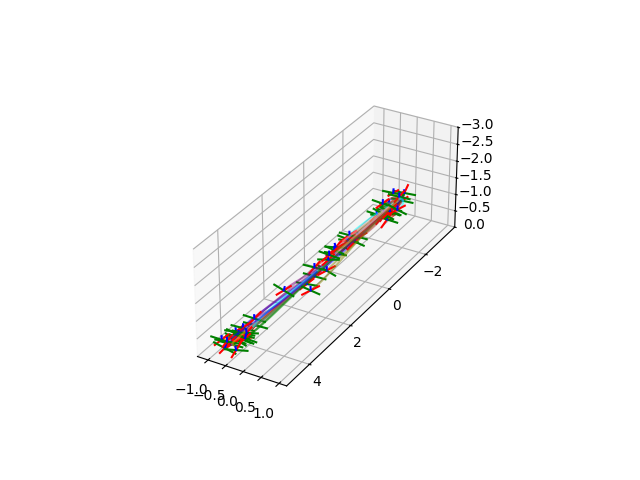

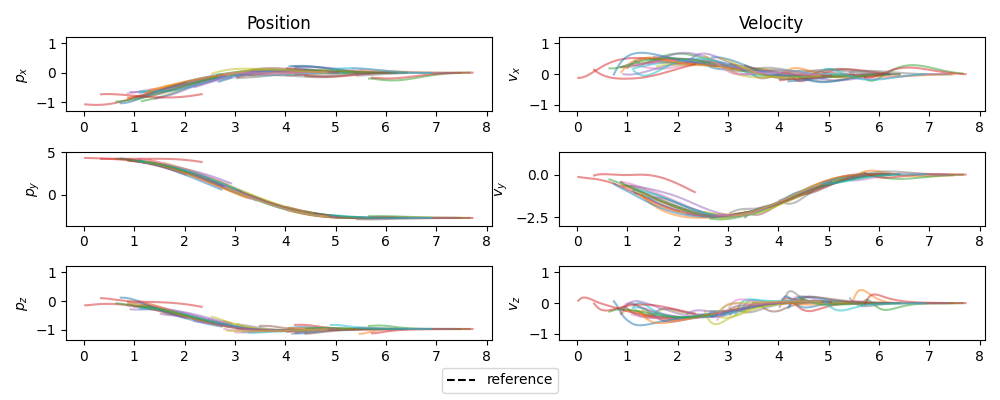

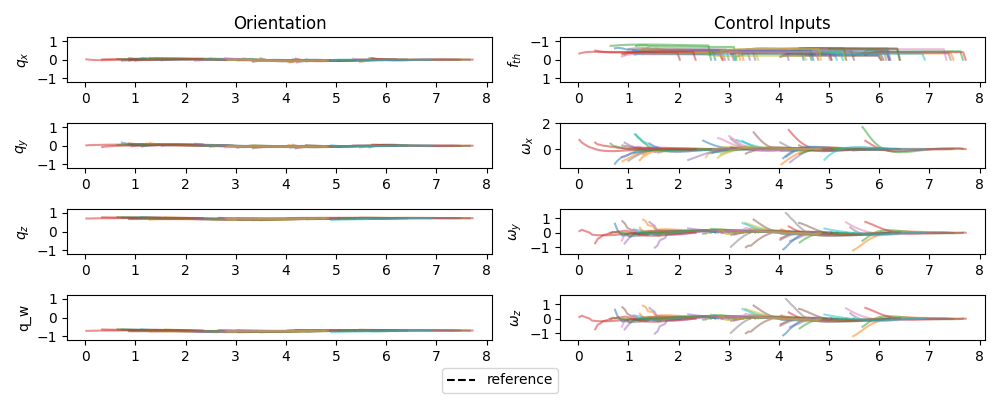

Rollout produced 12 datasets with the following courses: 
aerialarena_test(23080 dpts) [12 datasets]

In [6]:

# Review the Rollout Data
ps.plot_rollout_data(cohort)

#### 4. Extract observation data.

We next extract the relevant data for each pilot. Users can configure their learned policies to use a variety of inputs. This function call extracts said inputs specific to each pilot from the raw rollout data. This allows you to test multiple learned policies from a single set of raw rollouts.

In [7]:
# Generate Observation Data
og.generate_observation_data(cohort,roster)

Generating observation data with subsample ratio 1.0 for...
 Cohort : aerial_arena
 Roster : ['Maverick']
 Courses: ['aerialarena_test']

Output()

#### 5. Train the histNet

The best policy we found has two distinct networks that are trained separately. Here we train the first network, the histNet, which does a form of online rapid-motor-adaptation using a latent estimate of the drone's parameters. You can run the train_roster command multiple times to continue training the histNet. If you want to start from scratch, simply delete the histNet in the corresponding $course/roster/$pilot folder.

Use the plot function to review the current network's train/eval losses.

In [10]:
# Train the Policy
tp.train_roster(cohort,roster,"histNet",200)

# Plot the histNet losses
pl.plot_losses(cohort,roster,"histNet",use_log=True)

Using existing observation data...

Output()

KeyboardInterrupt: 

#### 6. Train the commNet

Here we train the second network, commNet, which contains the bulk of the parameters for the visuomotor policy. We also show a deployment evaluation option for training where we simulate the policy in FiGS at the save intervalsand use trajectory tracking error to grade policy performance. The best performing policy will be the final one that gets saved. Just like with histNet, re-running the train_roster function will load and train an existing network and if you want to start from scratch, delete the commNet file in the corresponding $course/roster/$pilot folder.

It is important to note that regen should be set to True every time you start training commNet right after a histNet training session. This is because the outputs of the histNet network will have changed.

Use the plot function to review the current network's train/eval losses.

Regenerating observation data...

Generating observation data with subsample ratio 1.0 for...
 Cohort : aerial_arena
 Roster : ['Maverick']
 Courses: ['aerialarena_test']

Output()

Loading trajectory data from trajectories001.pt and image data from images001.pt...

Loading trajectory data from trajectories002.pt and image data from images002.pt...

...

✅ Done loading checkpoint from 
outputs/aerialarena_square_16x/splatfacto/2026-07-30_141201_clean/nerfstudio_models/step-000059999.ckpt

/home/airlab/SousVide/.venv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in
x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)

/home/airlab/SousVide/.venv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in
x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)

Maverick > commNet : Best checkpoint is commNet_ckpt300.

======================================================================
Cohort : aerial_arena           Network: commNet
======================================================================
----------------------------------------------------------------------
Student: Maverick   | Epochs: 300   | Data Size: 22336.0/1216.0               
Time: 0h 58m 24s    | Train: 0.0014 | Test: 0.0074 | Eval TTE: 4.78
======================================================================

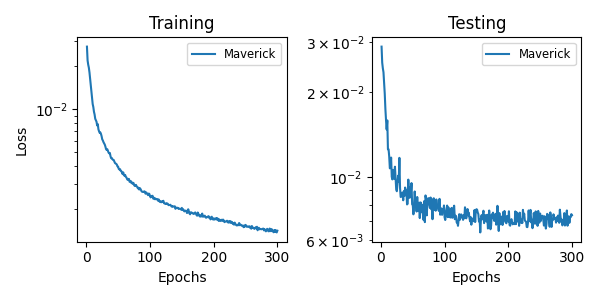

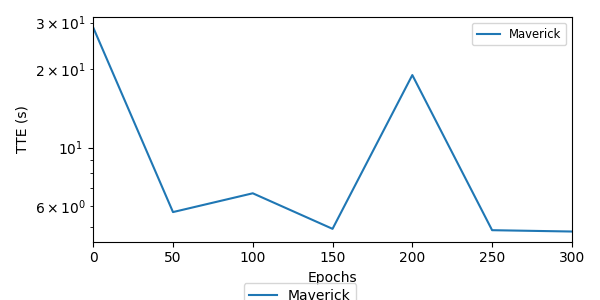

In [11]:
# Train the Policy
tp.train_roster(
    cohort,roster,"commNet",300,
    regen=True,
    deployment=(courses[0],scene,eval_method))

# Plot the commNet losses
pl.plot_losses(cohort,roster,"commNet",use_log=True)

#### 7. Evaluate using FiGS

Run an evalution using FiGS simulations and plot some useful data. Video of last policy rollout(s) can be found in $course/deployment_data.

Loading latest checkpoint from load_dir

✅ Done loading checkpoint from 
outputs/aerialarena_square_16x/splatfacto/2026-07-30_141201_clean/nerfstudio_models/step-000059999.ckpt

/home/airlab/SousVide/.venv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/home/airlab/SousVide/.venv/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


Plotting trajectories for expert...

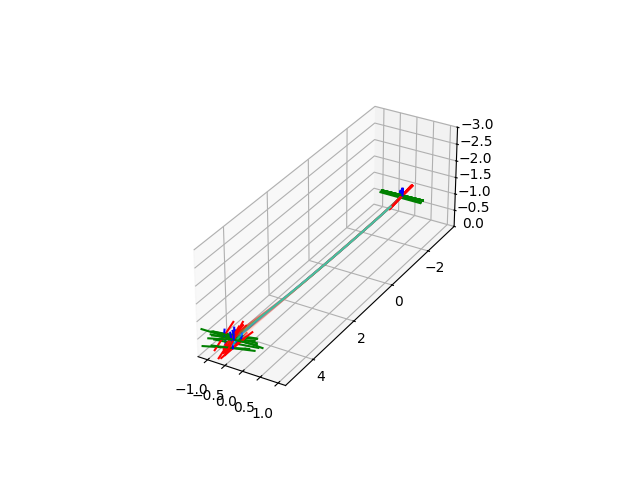

Plotting trajectories for Maverick...

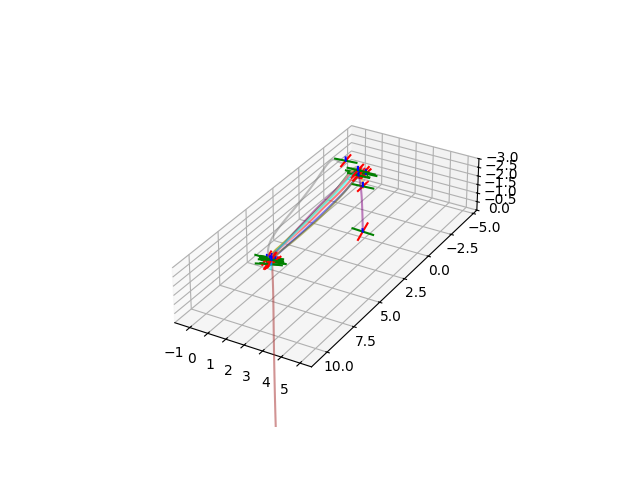

                      Deployment Summary                      
┏━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┓
┃ Pilot    ┃ TTE Mean ┃ TTE Best ┃  PP  ┃ Hz Mean ┃ Hz Worst ┃
┡━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━━━┩
│ expert   │   5.49   │   5.13   │ 0.00 │  1.91   │   1.82   │
│ Maverick │   5.77   │   4.53   │ 0.00 │  6.25   │   6.05   │
└──────────┴──────────┴──────────┴──────┴─────────┴──────────┘

In [12]:
# Simulate in FiGS
for course in courses:
    df.deploy_roster(cohort,course,scene,eval_method,roster,mode="visualize")
    pl.plot_deployments(cohort,course,roster,plot_show=True)